# IAGA-2002 Download Tutorial

This notebook demonstrates `magie.download_iaga2002`, which downloads MAGIE IAGA-2002 files, reads them with MagPy, joins multiple archive days with `join_streams`, and returns a MagPy `DataStream`.

The example uses a short time window so it is quick to run. Downloaded files are saved under `notebooks/iaga_download_example/` by default.

In [1]:
from magie import download_iaga2002
from magie.Plotting_Tools import plot_BxByBz, plot_dH

## Download One Short Window

`start` and `end` may be strings, `datetime` objects, or pandas timestamps. Timezone-aware inputs are converted to UTC archive days before downloading. Naive inputs are treated as UTC.

The downloader checks candidate IAGA filenames in priority order. The defaults look for provisional second files first, then provisional minute files: `psec.sec`, `pmin.min`.

In [2]:
site_code = "dun"
start = "2026-07-01T00:00:00"
end = "2026-07-05T00:10:00"
stream = download_iaga2002(
    start,
    end,
    site_code,
    save=True,
    save_dir='./',
    n_jobs=2,
)

stream

[array([datetime.datetime(2026, 7, 1, 6, 50, 21),
        datetime.datetime(2026, 7, 1, 6, 50, 22),
        datetime.datetime(2026, 7, 1, 6, 50, 23), ...,
        datetime.datetime(2026, 7, 5, 0, 9, 58),
        datetime.datetime(2026, 7, 5, 0, 9, 59),
        datetime.datetime(2026, 7, 5, 0, 10)],
       shape=(321580,), dtype=object)
 array([19045.21, 19045.15, 19045.06, ..., 19025.13, 19025.12, 19025.12],
       shape=(321580,), dtype=object)
 array([229.12, 229.15, 229.15, ..., 215.55, 215.56, 215.57],
       shape=(321580,), dtype=object)
 array([48039.37, 48039.47, 48039.51, ..., 48050.78, 48050.74, 48050.75],
       shape=(321580,), dtype=object)
 array([51677.4, 51677.47, 51677.47, ..., 51680.55, 51680.51, 51680.52],
       shape=(321580,), dtype=object)
 array([], dtype=float64) array([], dtype=float64)
 array([], dtype=float64) array([], dtype=float64)
 array([], dtype=float64) array([], dtype=float64)
 array([], dtype=float64) array([], dtype=float64)
 array([], dtype=float6

## Confirm What Was Saved

With `save=True`, the raw IAGA-2002 files are retained in `save_dir`. Use `save=False` if you only want the returned `DataStream` and do not want to keep the downloaded files.

In [3]:
from pathlib import Path
download_dir = Path("./")
saved_files = sorted(download_dir.glob(f"{site_code}*.sec")) + sorted(download_dir.glob(f"{site_code}*.min"))
saved_files

[PosixPath('dun20260701psec.sec'),
 PosixPath('dun20260702psec.sec'),
 PosixPath('dun20260703psec.sec'),
 PosixPath('dun20260704psec.sec'),
 PosixPath('dun20260705psec.sec')]

## Inspect The Returned DataStream

MagPy stores data columns internally by key. Here we print the first few timestamps and magnetic components directly from the returned `DataStream`.

In [4]:
import numpy as np

if stream is None:
    print("No DataStream was returned.")
else:
    n = min(10, len(stream["time"]))
    print(f"Samples in returned DataStream: {len(stream['time'])}")
    print("datetime:", np.asarray(stream["time"])[:n])
    print("x:", np.asarray(stream["x"])[:n])
    print("y:", np.asarray(stream["y"])[:n])
    print("z:", np.asarray(stream["z"])[:n])

Samples in returned DataStream: 321580
datetime: [datetime.datetime(2026, 7, 1, 6, 50, 21)
 datetime.datetime(2026, 7, 1, 6, 50, 22)
 datetime.datetime(2026, 7, 1, 6, 50, 23)
 datetime.datetime(2026, 7, 1, 6, 50, 24)
 datetime.datetime(2026, 7, 1, 6, 50, 25)
 datetime.datetime(2026, 7, 1, 6, 50, 26)
 datetime.datetime(2026, 7, 1, 6, 50, 27)
 datetime.datetime(2026, 7, 1, 6, 50, 28)
 datetime.datetime(2026, 7, 1, 6, 50, 29)
 datetime.datetime(2026, 7, 1, 6, 50, 30)]
x: [19045.21 19045.15 19045.06 19045.04 19045.05 19045.01 19044.97 19044.88
 19044.87 19044.83]
y: [229.12 229.15 229.15 229.17 229.18 229.17 229.17 229.21 229.24 229.26]
z: [48039.37 48039.47 48039.51 48039.46 48039.23 48039.01 48038.91 48038.93
 48038.93 48038.85]


In [5]:
print("Available DataStream keys with data:")
print([key for key in stream.KEYLIST if len(stream[key])])

Available DataStream keys with data:
['time', 'x', 'y', 'z', 'f']


## Plot With MAGIE Helpers

`plot_BxByBz` plots the vector components. `plot_dH` plots declination, horizontal intensity, and the first difference of horizontal intensity.

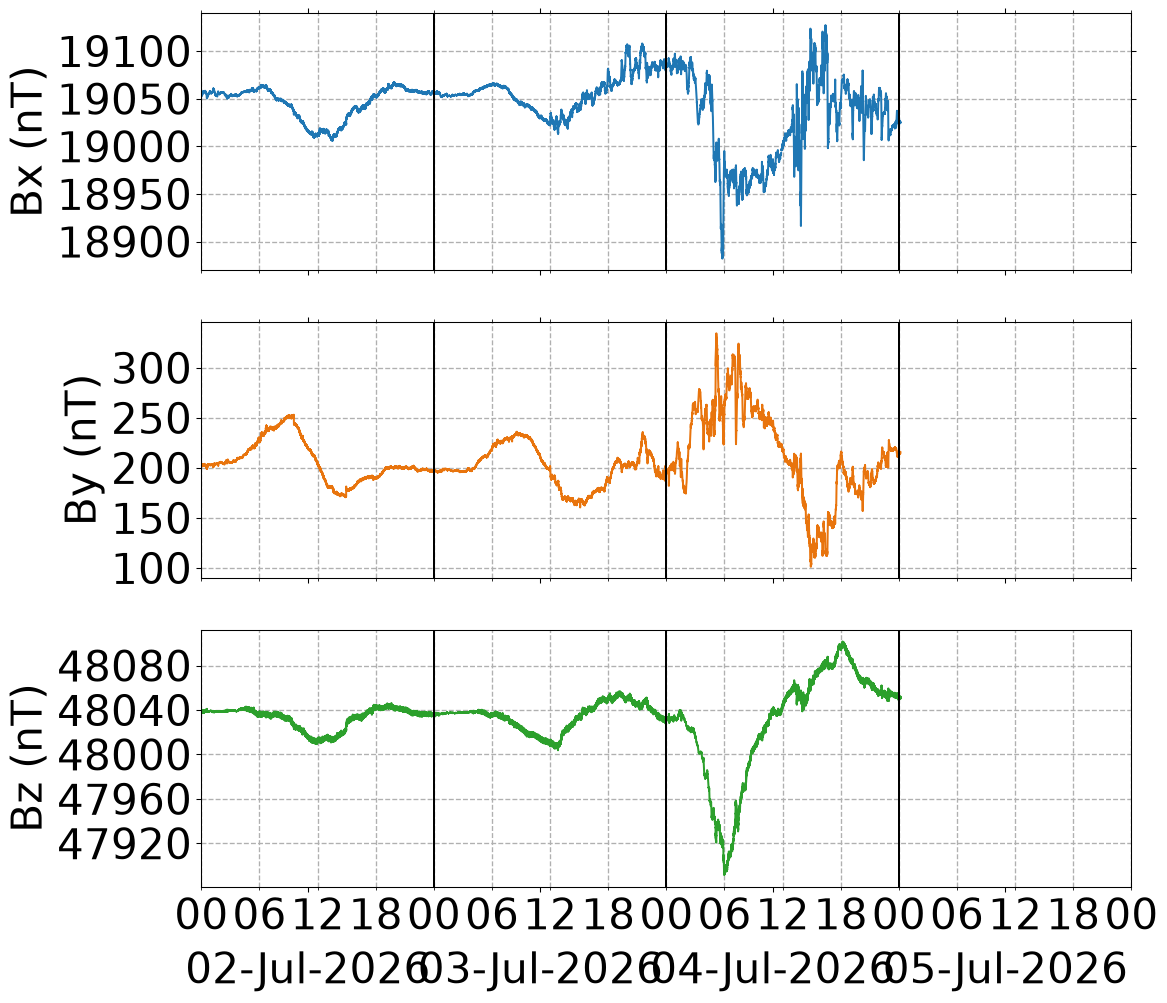

In [6]:
fig_b, ax_bx, ax_by, ax_bz = plot_BxByBz(stream, show_logo=False, filter=False)
# fig_b.suptitle(f"{site_code.upper()} Bx, By, Bz from IAGA-2002 download")

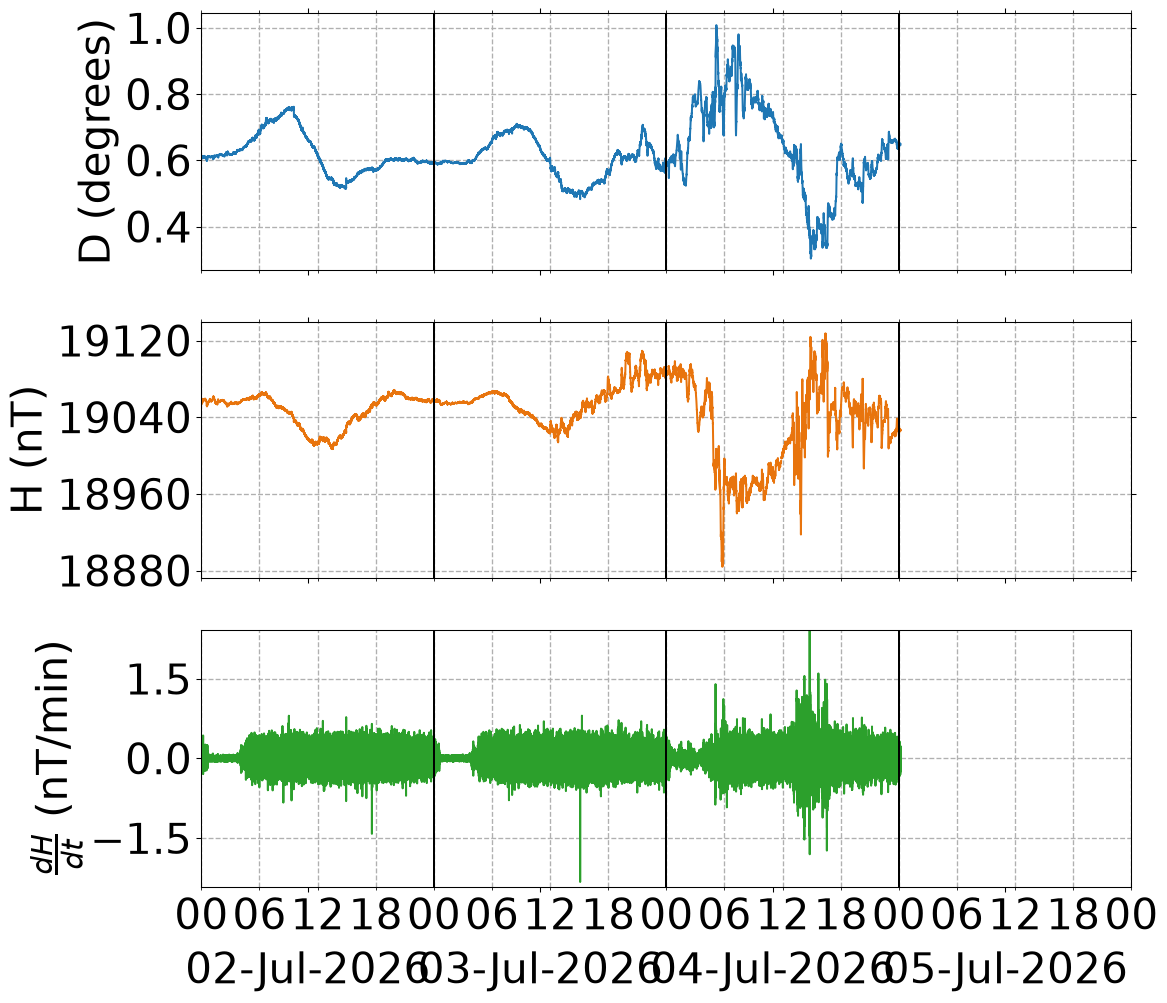

In [7]:
fig_dh, ax_d, ax_h, ax_dh = plot_dH(stream, show_logo=False, filter=False)
# fig_dh.suptitle(f"{site_code.upper()} dH summary from IAGA-2002 download")

## Common Variations

Use `save=False` to download into a temporary directory and return only the joined `DataStream`:

```python
stream = download_iaga2002(start, end, site_code, save=False)
```

Use `data_types` to try other IAGA type codes before falling back to provisional files:

```python
stream = download_iaga2002(start, end, site_code, data_types=("v", "p"))
```

Use `intervals` to prefer minute data over second data:

```python
stream = download_iaga2002(start, end, site_code, intervals=("min", "sec"))
```